# Neural Network - Student Health Risk

Dataset: Kaggle S6E7 (student health risk)
Target: health_condition (fit / at-risk / unhealthy)
Need train.csv in same folder.


1. Imports


In [18]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42


2. Load data


In [19]:
students = pd.read_csv("train.csv")

NUMERIC_FEATURES = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
                     "step_count", "exercise_duration", "water_intake"]
CATEGORICAL_FEATURES = ["diet_type", "stress_level", "sleep_quality",
                         "physical_activity_level", "smoking_alcohol", "gender"]

for col in NUMERIC_FEATURES:
    students[col] = students[col].fillna(students[col].median())
for col in CATEGORICAL_FEATURES:
    students[col] = students[col].fillna("missing")

print("Shape:", students.shape)
print(students["health_condition"].value_counts(normalize=True).round(3))


Shape: (690088, 15)
health_condition
at-risk      0.859
unhealthy    0.084
fit          0.058
Name: proportion, dtype: float64


3. Split data

Using 150k rows sample so it trains faster.


In [20]:
students_sample, _ = train_test_split(
    students, train_size=150_000,
    stratify=students["health_condition"], random_state=RANDOM_STATE
)

X = students_sample[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = students_sample["health_condition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

target_encoder = LabelEncoder()
y_train_enc = target_encoder.fit_transform(y_train)
y_test_enc = target_encoder.transform(y_test)

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Class mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


Train rows: 112500
Test rows: 37500
Class mapping: {'at-risk': np.int64(0), 'fit': np.int64(1), 'unhealthy': np.int64(2)}


4. Preprocessing

NN is sensitive to scale, so numeric cols are standardized (mean 0, std 1). Categorical cols one-hot encoded.


In [21]:
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", StandardScaler(), NUMERIC_FEATURES),
])


5. Train model


In [22]:
model_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=1e-4, learning_rate_init=1e-3, max_iter=100, early_stopping=True, n_iter_no_change=8, random_state=RANDOM_STATE))
])

model_pipeline.fit(X_train, y_train_enc)
print("Training complete.")


Training complete.


6. Evaluate


In [23]:
y_pred = model_pipeline.predict(X_test)
y_pred_labels = target_encoder.inverse_transform(y_pred)
y_proba = model_pipeline.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred_labels)
precision = precision_score(y_test, y_pred_labels, average="macro")
recall = recall_score(y_test, y_pred_labels, average="macro")
f1 = f1_score(y_test, y_pred_labels, average="macro")
roc_auc = roc_auc_score(y_test_enc, y_proba, multi_class="ovr", average="macro")

print(f"Accuracy:            {accuracy:.4f}")
print(f"Precision (macro):   {precision:.4f}")
print(f"Recall (macro):      {recall:.4f}")
print(f"F1 Score (macro):    {f1:.4f}")
print(f"ROC-AUC (OvR macro): {roc_auc:.4f}")


Accuracy:            0.9641
Precision (macro):   0.9527
Recall (macro):      0.8567
F1 Score (macro):    0.8997
ROC-AUC (OvR macro): 0.9802


7. Confusion matrix


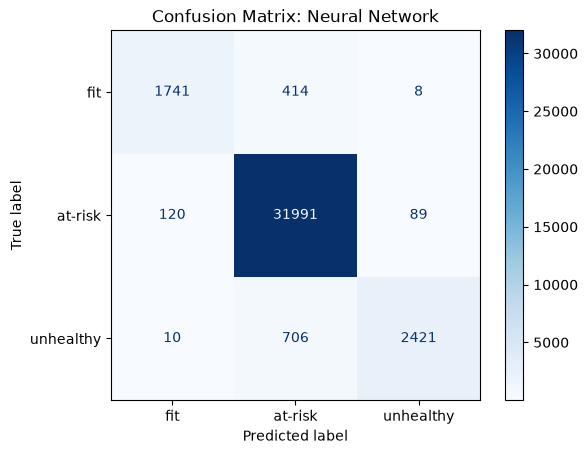

In [24]:
cm = confusion_matrix(y_test, y_pred_labels, labels=["fit", "at-risk", "unhealthy"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["fit", "at-risk", "unhealthy"])
disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix: Neural Network")
plt.show()


8. Classification report


In [25]:
print(classification_report(y_test, y_pred_labels, target_names=["at-risk", "fit", "unhealthy"]))


              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98     32200
         fit       0.93      0.80      0.86      2163
   unhealthy       0.96      0.77      0.86      3137

    accuracy                           0.96     37500
   macro avg       0.95      0.86      0.90     37500
weighted avg       0.96      0.96      0.96     37500



9. Feature importance


In [26]:
feature_names = model_pipeline.named_steps["preprocess"].get_feature_names_out()
fitted_model = model_pipeline.named_steps["model"]

# NN has no feature_importances_ like trees do
print(f"Network shape: {fitted_model.n_features_in_} inputs -> {fitted_model.hidden_layer_sizes} -> {fitted_model.n_outputs_} outputs")


Network shape: 31 inputs -> (64, 32) -> 3 outputs


10. Predict new students


In [27]:
new_students = pd.DataFrame({
    "sleep_duration": [7.5, 6.5, 5.0],
    "heart_rate": [70, 78, 95],
    "bmi": [21.5, 24.0, 31.0],
    "calorie_expenditure": [2400, 2200, 1800],
    "step_count": [9500, 6000, 3000],
    "exercise_duration": [45, 25, 5],
    "water_intake": [2.5, 2.0, 1.2],
    "diet_type": ["balanced", "non-veg", "non-veg"],
    "stress_level": ["low", "medium", "high"],
    "sleep_quality": ["good", "average", "poor"],
    "physical_activity_level": ["active", "moderate", "sedentary"],
    "smoking_alcohol": ["no", "occasional", "yes"],
    "gender": ["male", "female", "female"],
})

predictions = model_pipeline.predict(new_students)
predictions = target_encoder.inverse_transform(predictions)
probabilities = model_pipeline.predict_proba(new_students)

classes = target_encoder.classes_
for i, (pred, probs) in enumerate(zip(predictions, probabilities), start=1):
    prob_str = ", ".join(f"{c}={p:.2f}" for c, p in zip(classes, probs))
    print(f"Student {i}: Predicted = {pred}  ({prob_str})")


Student 1: Predicted = fit  (at-risk=0.00, fit=1.00, unhealthy=0.00)
Student 2: Predicted = at-risk  (at-risk=1.00, fit=0.00, unhealthy=0.00)
Student 3: Predicted = unhealthy  (at-risk=0.00, fit=0.00, unhealthy=1.00)


11. Save model


In [ ]:
joblib.dump({
    "pipeline": model_pipeline,
    "target_encoder": target_encoder,
    "model_name": "Neural Network",
    "feature_columns": NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "target_classes": list(classes),
    "test_accuracy": accuracy,
    "test_macro_f1": f1,
    "test_roc_auc_ovr": roc_auc,
}, "neural_network_model.pkl")

print("Saved neural_network_model.pkl")
print(f"Final results - Accuracy: {accuracy:.4f}, Macro F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")


Saved neural_network_model.pkl
Final results — Accuracy: 0.9641, Macro F1: 0.8997, ROC-AUC: 0.9802


12. Summary

Trained, evaluated, saved model.
